## **Assignment #2: Classification, Regression, Clustering, Evaluation**

<br>

### **Overview**

In this assignment, you'll level up your data science toolkit. While the first assignment focused on the data, on this one you will practice:

- Classification models

- Regression models

- Feature Engineering

- Evaluations

You’ll go from raw data to insights by building a full modeling pipeline, enhancing your dataset, and training different models.

This assignment will be completed individually.

### **Objectives**

You’ll gain hands-on experience in:
- Evaluation
- Classification
- Regression
- Dataset preparation
- Explore various data hubs
- Engineering meaningful features
- Communicating findings clearly - visually and verbally

<br><br>

### **Submission Guidelines**

1. Please note that this assignmnet must be submitted alone.
2. Link to your HugingFace Model.

Your HF model should include:
- README file: explanations, visuals, insights, etc.
- **Video**: Include the video of your presentation in the README file.
- **Python Notebook**: upload a copy of this notebook, with all of your coding work. Do not submit a Colab link; include the `.ipynb` file in the HF model.
- **ML Models:** Upload your models.

Note: Students may be randomly chosen to present their work in a quick online session with the T.A., typically lasting ±10 minutes. Similar to Peer Review.

<br><br>



### **Evaluation Criteria**

* **Data Handling & EDA (20%)**
  Thoughtful and thorough data cleaning; handling of missing values, outliers, duplicates, and more; well-chosen visualizations; clear statistical summaries; use of EDA to guide modeling choices.

* **Feature Engineering (20%)**
  Creative and effective feature creation, transformation, encoding, selection, scaling, and more; integration of clustering results as features; clear explanation of feature choices and their impact.

* **Model Training (20%)**
  Appropriate selection of models; correct train/test split; reproducible code; logical modeling workflow with a solid baseline and improvements post-feature engineering. An iterative process.

* **Evaluation & Interpretation (20%)**
  Use of relevant evaluation metrics; structured model comparison; use of feature importance or visualizations to interpret results; clear discussion of what the model learned and how it performed.

* **Presentation (20%)**
  4–6 minute video with clear delivery; structured narrative; visuals that support the explanation; confident, professional communication of findings and lessons.

* **Bonus (up to +10%)**
  Extra work such as trying data science tools, creative visualizations, advanced hyper param tuning, interactive dashboards, and deeper business/ethical insights.

* **Late Submission (-10% per day)**
  Assignments submitted after the deadline will receive a 10% penalty per day.

<br><br>

### **Additional Guidelines**

- The first thing you should do is download a copy of this notebook to your drive.
- Keep your dataset size manageable. If the dataset is too large, you can sample a subset.
- Run on Colab (CPU is fine). Colab free is enough. No GPU needed.
- You may use any Python package (scikit-learn, xgboost, lightgbm, catboost, etc.).
- No SHAP required. Use `feature_importances`, and similar tools.
- Make sure your results are reproducible (set **seeds** where needed).
- Be thoughtful with your cluster features — only use them if they help!
- Your presentation should tell a story; what worked, what didn’t, and why.
- Be creative, but also rigorous.

### Assignment High-level Flow

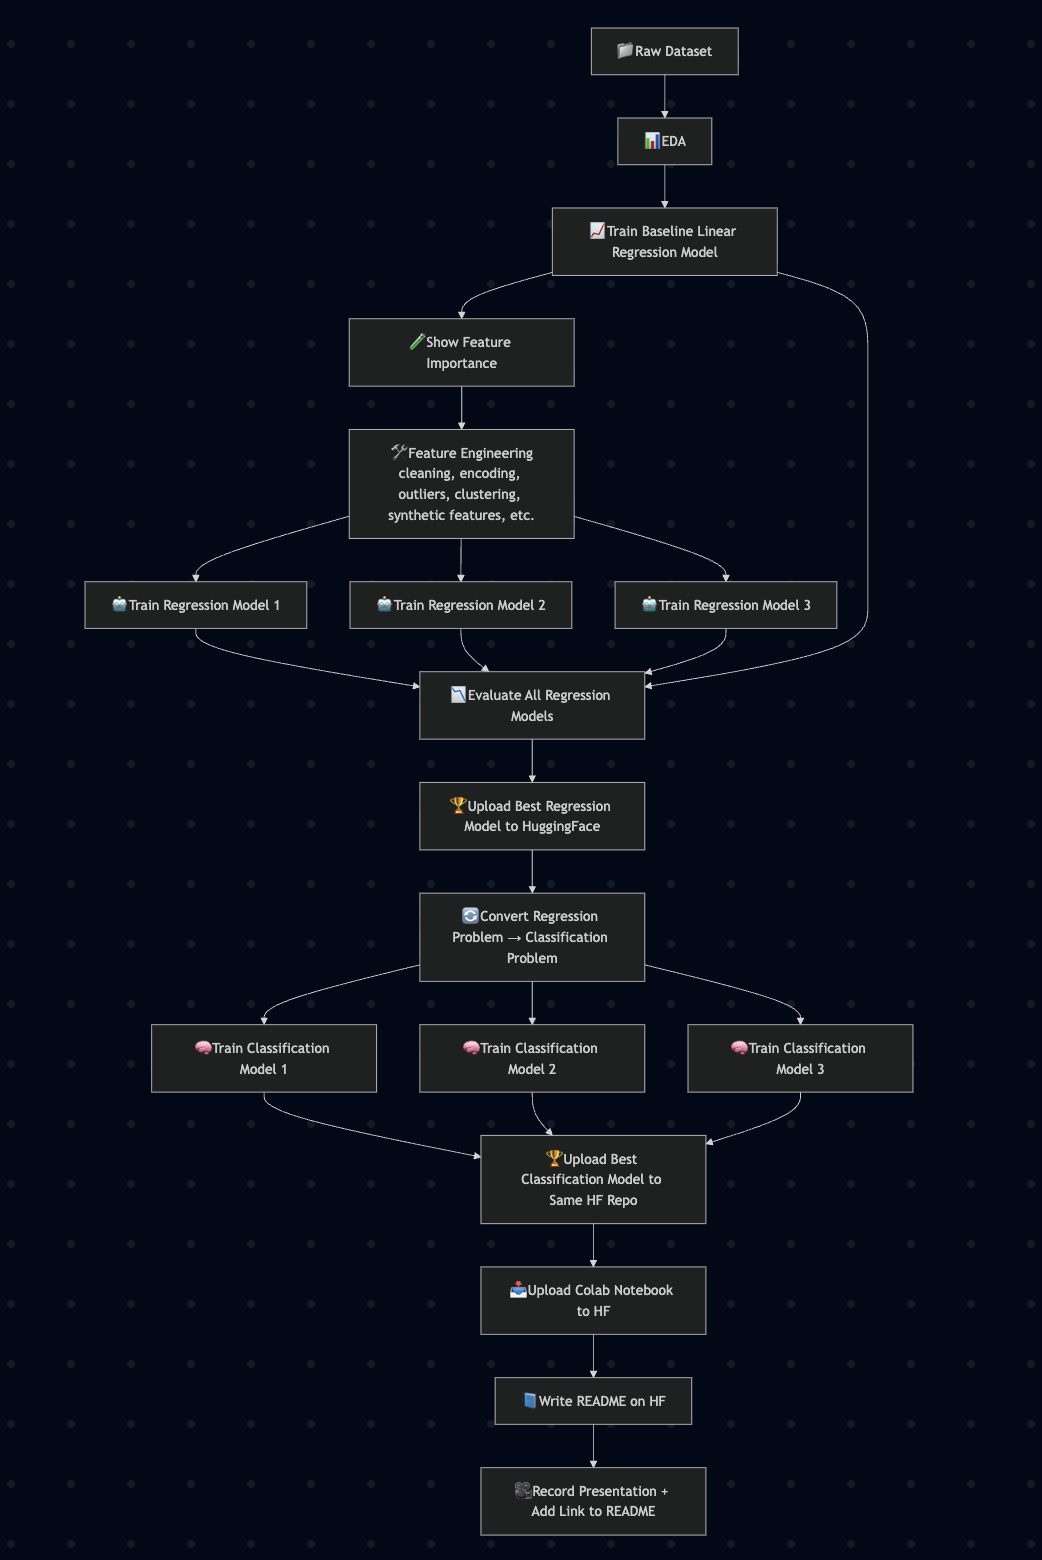

<br><br><br>

---

---

<br><br><br>

imports

In [ ]:
import os
import random

import numpy as np
import pandas as pd

import seaborn
import matplotlib.pyplot as plt

# <add more>

Set Seeds

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# <add more>

For Jupyter Notebooks

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

Warnings

In [ ]:
import warnings
warnings.filterwarnings('ignore')

<br><br>

---

<br><br>

# **Part 1: Select a Regression Dataset**

1. Choose a numeric & categorical tabular dataset. If you prefer, you may use  open-source datasets; [Hugginface](https://huggingface.co/datasets?task_categories=task_categories:tabular-classification&sort=trending), [Kaggle](https://www.kaggle.com/datasets?tags=13302-Classification&minUsabilityRating=8.00+or+higher), etc.

2. Avoid choosing a "basic"/"small" dataset.
      - 10K rows and more.
      - 15 features and more.
      - Numeric & Categorial features are a must.

3. The Label (target variable) is numeric.

4. Please submit your dataset [here](https://forms.gle/YYiRLXJnbwUfwuwc7), to share it with the class so everyone can see.
And make sure your chosen dataset is unique using this [link](https://docs.google.com/spreadsheets/d/1M8uojrzhSyVnOlSAJpzCKxrhWdzPR77k4x8Kxvr8VDk/edit?usp=sharing).

      *Note: Due to their popularity, the following are datasets you may not choose.*
      > - Iris dataset
      > - Wine dataset
      > - Titanic dataset
      > - Boston Housing dataset

5. Choose a dataset with a combination of numeric and textual values. This way you would have enough information to work on.

6. Briefly describe your chosen dataset (source, size, features) and the question you want to answer.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile("archive (1).zip", 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
df = pd.read_csv("data_car.csv")
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


###Dataset Source:  
The dataset was taken from Kaggle (Car Features and MSRP dataset).

###Dataset Description:
The dataset contains 11,914 observations and 16 features, including both numerical and categorical variables such as engine horsepower, fuel type, transmission type, vehicle size, and market category.  
The target variable is MSRP, representing the car's market price.

###Objective / Research Question:
The goal of this project is to predict a car’s market price (MSRP) based on its technical specifications and categorical features. Additionally, the project aims to identify the key factors that influence car pricing.

Dataset Link:
https://www.kaggle.com/datasets/CooperUnion/cardataset

<br><br><br>

---

<br><br><br>

# **Part 2: Exploratory Data Analysis (EDA)**

Use your EDA to tell the story of your data - highlight interesting patterns, anomalies, or relationships that lead you toward your classification goal. Ask interesting questions, and answer them.


1. **Data Cleaning** : Check for missing values, duplicate entries, scaling/normalize issues,  parsing dates, fixing typos, or any inconsistencies.  Document how you address them.
2. **Outlier Detection & Handling**: Identify outliers and decide whether to keep or remove them, providing a short justification.
2. **Descriptive Statistics**: Summarize the data (e.g., mean, median, correlations) to reveal patterns.
4. **Visualizations**: Use a set of  plots (e.g., histograms, scatter plots, box plots) to illustrate **key insights.** Label charts, axes, and legends clearly.

Tip: not necessarily in this order.

## Part 2: Exploratory Data Analysis (EDA)

In this section, we explore the dataset, identify data quality issues, and prepare the data for further analysis and modeling.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [ ]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
Engine Fuel Type,3
Engine HP,69
Engine Cylinders,30
Transmission Type,0
Driven_Wheels,0
Number of Doors,6
Market Category,3742


In [ ]:
df.duplicated().sum()

np.int64(715)

### Data Overview

The dataset contains both numerical and categorical features.  
We identified missing values in several columns such as "Market Category", "Engine HP", and "Engine Cylinders".  

Additionally, 715 duplicate rows were found in the dataset, which could negatively affect the analysis and model performance.

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Fill categorical missing
df["Market Category"] = df["Market Category"].fillna("Unknown")
df["Engine Fuel Type"] = df["Engine Fuel Type"].fillna(df["Engine Fuel Type"].mode()[0])

# Fill numeric missing with median
df["Engine HP"] = df["Engine HP"].fillna(df["Engine HP"].median())
df["Engine Cylinders"] = df["Engine Cylinders"].fillna(df["Engine Cylinders"].median())
df["Number of Doors"] = df["Number of Doors"].fillna(df["Number of Doors"].median())

In [ ]:
df.isnull().sum()

,0
Make,0
Model,0
Year,0
Engine Fuel Type,0
Engine HP,0
Engine Cylinders,0
Transmission Type,0
Driven_Wheels,0
Number of Doors,0
Market Category,0


In [ ]:
df.shape

(11199, 16)

### Data Cleaning

To improve data quality:

- Duplicate rows were removed to prevent bias.
- Missing values in categorical features were handled by filling with "Unknown".
- Missing values in numerical features were filled using the median to reduce the impact of outliers.

After cleaning, the dataset contains 11,199 rows with no missing values.

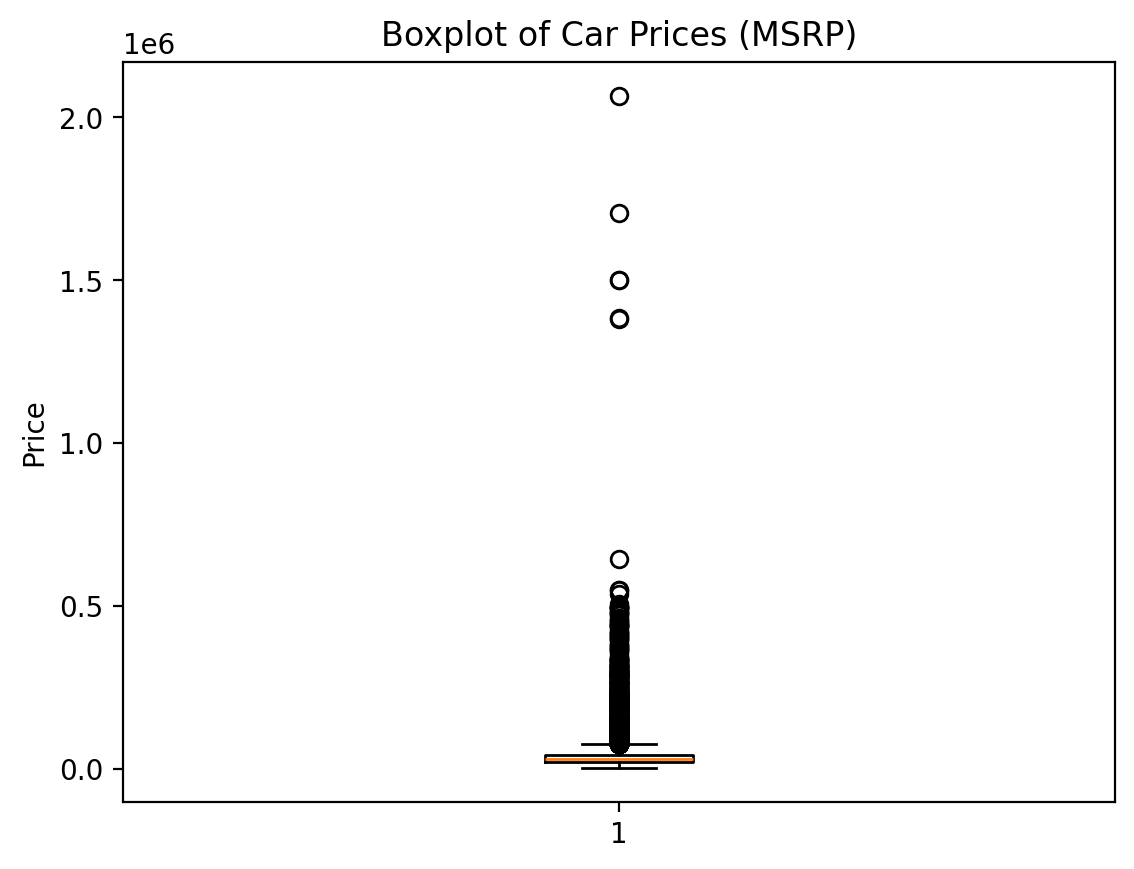

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df["MSRP"])
plt.title("Boxplot of Car Prices (MSRP)")
plt.ylabel("Price")
plt.show()

### Outlier Analysis

The boxplot of the MSRP variable shows a large number of extreme values (outliers), with some cars priced significantly higher than the majority.

This indicates a right-skewed distribution, where most vehicles are relatively affordable, while a small number of luxury or high-performance cars have very high prices.

These outliers are valid observations and represent real high-end vehicles, therefore they were not removed.

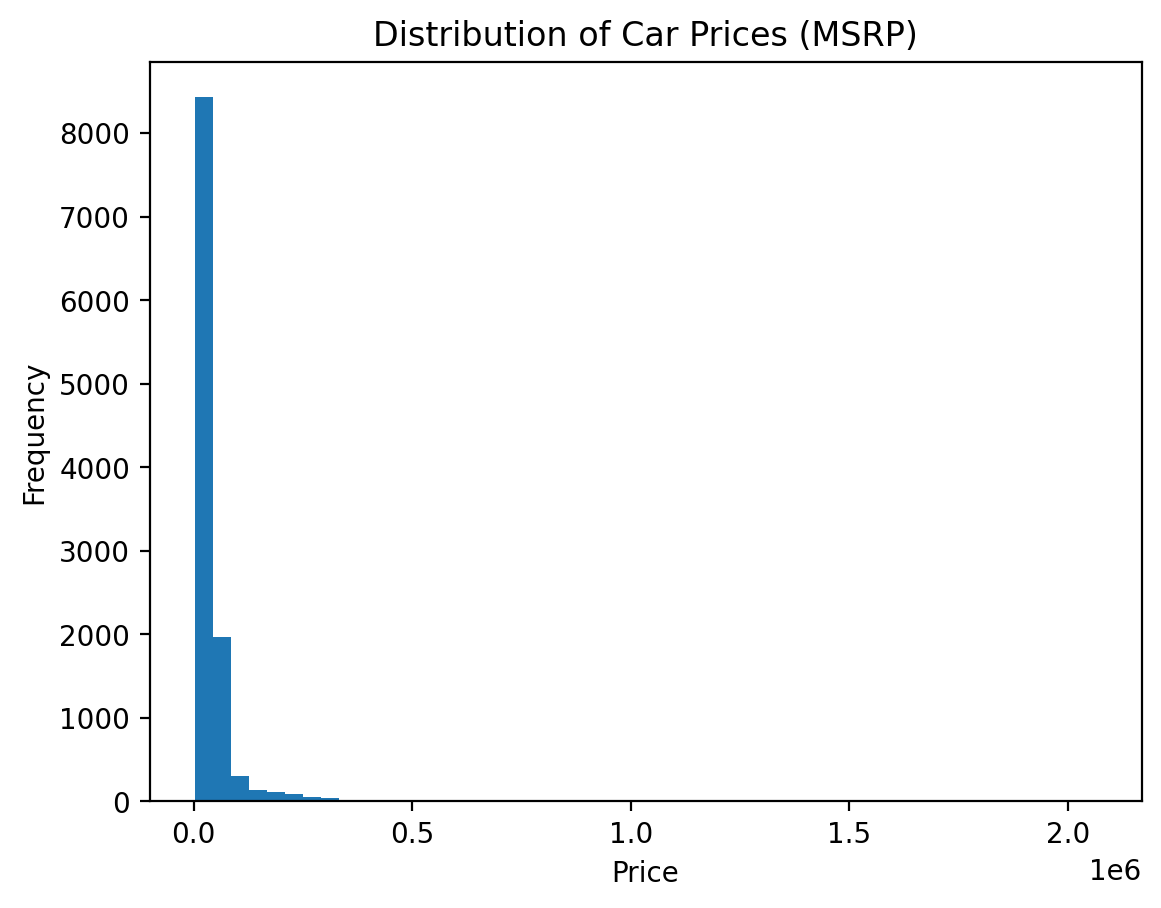

In [ ]:
plt.hist(df["MSRP"], bins=50)
plt.title("Distribution of Car Prices (MSRP)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [ ]:
import numpy as np

df["log_MSRP"] = np.log1p(df["MSRP"])

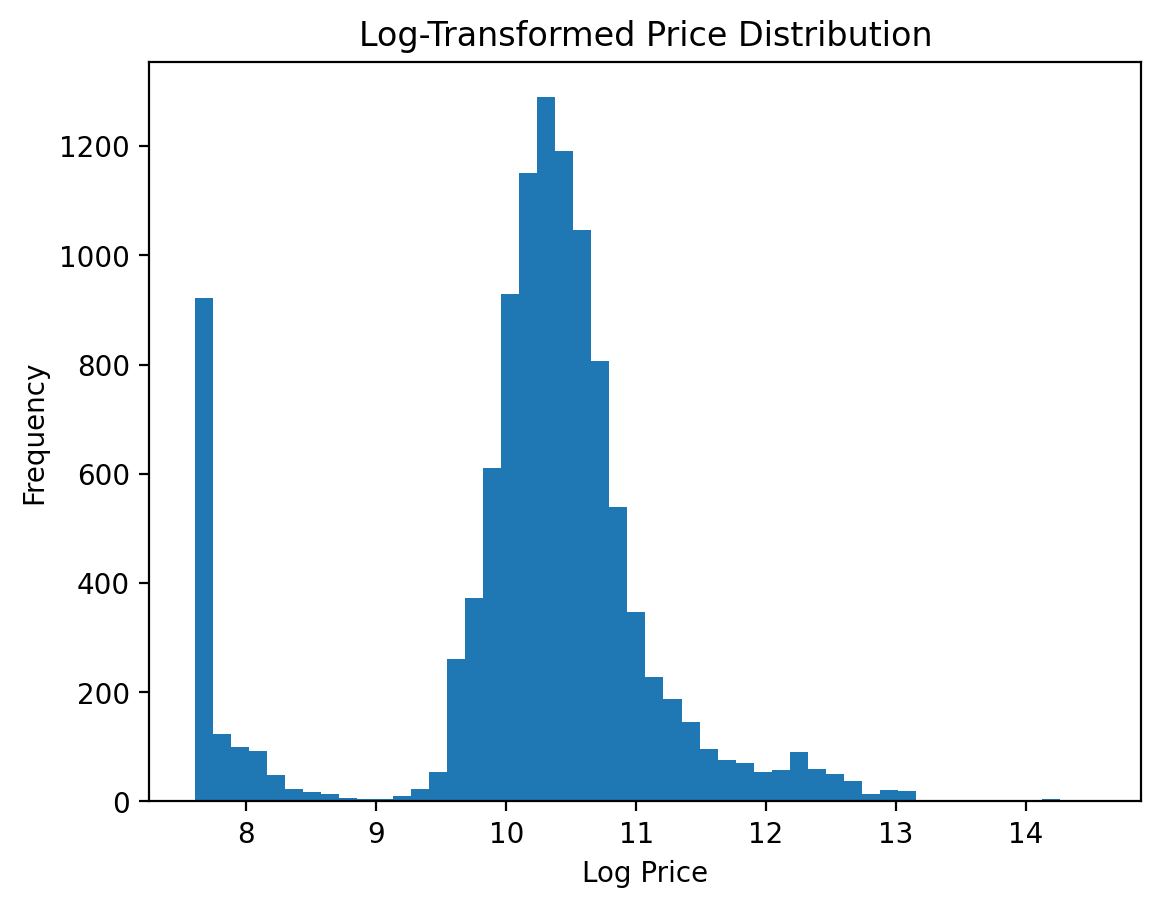

In [ ]:
plt.hist(df["log_MSRP"], bins=50)
plt.title("Log-Transformed Price Distribution")
plt.xlabel("Log Price")
plt.ylabel("Frequency")
plt.show()

### Log Transformation

The original MSRP distribution exhibited a strong right skew, with a small number of extremely high-priced vehicles.

To address this, a log transformation was applied to the MSRP variable. This transformation reduces the influence of extreme values and results in a more symmetric distribution, which is better suited for statistical analysis and machine learning models.

### Price Distribution

The distribution of the MSRP variable is highly right-skewed. Most cars are concentrated in the lower price range, while a small number of vehicles have extremely high prices.

This confirms the presence of outliers and indicates that the data is not normally distributed.

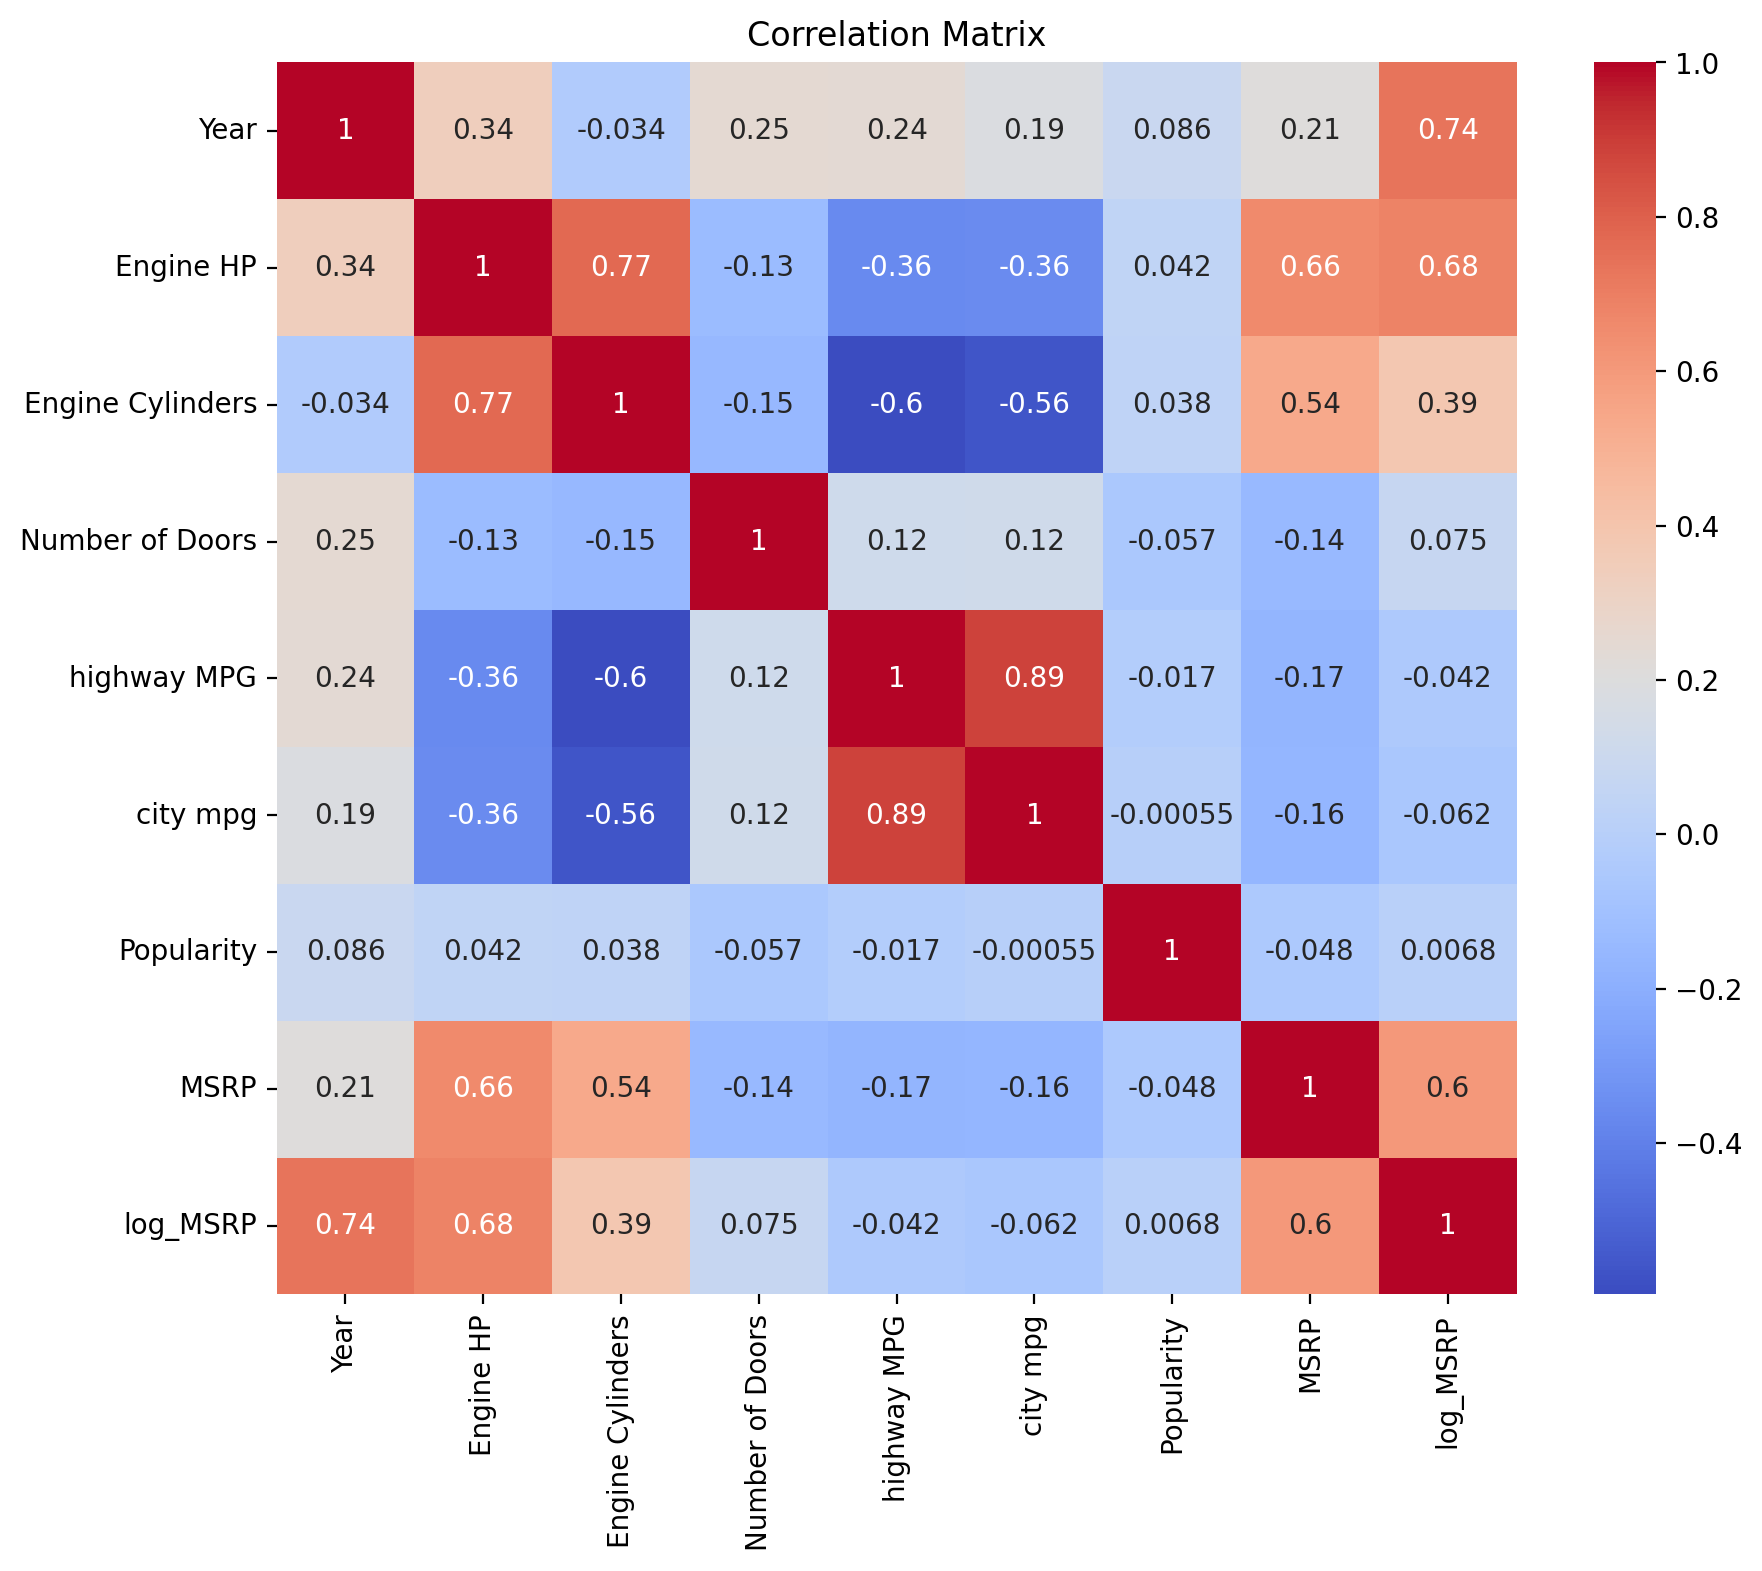

In [ ]:
import seaborn as sns

numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis

The correlation matrix reveals several important relationships between features and car prices.

Engine HP shows a strong positive correlation with MSRP, indicating that more powerful cars tend to be more expensive. Similarly, Engine Cylinders also has a positive relationship with price.

Year has a strong correlation with the log-transformed price, suggesting that newer vehicles are generally more expensive.

On the other hand, fuel efficiency variables such as highway MPG and city mpg show a negative correlation with price, indicating that more fuel-efficient cars tend to be cheaper.

Popularity appears to have little to no correlation with price.

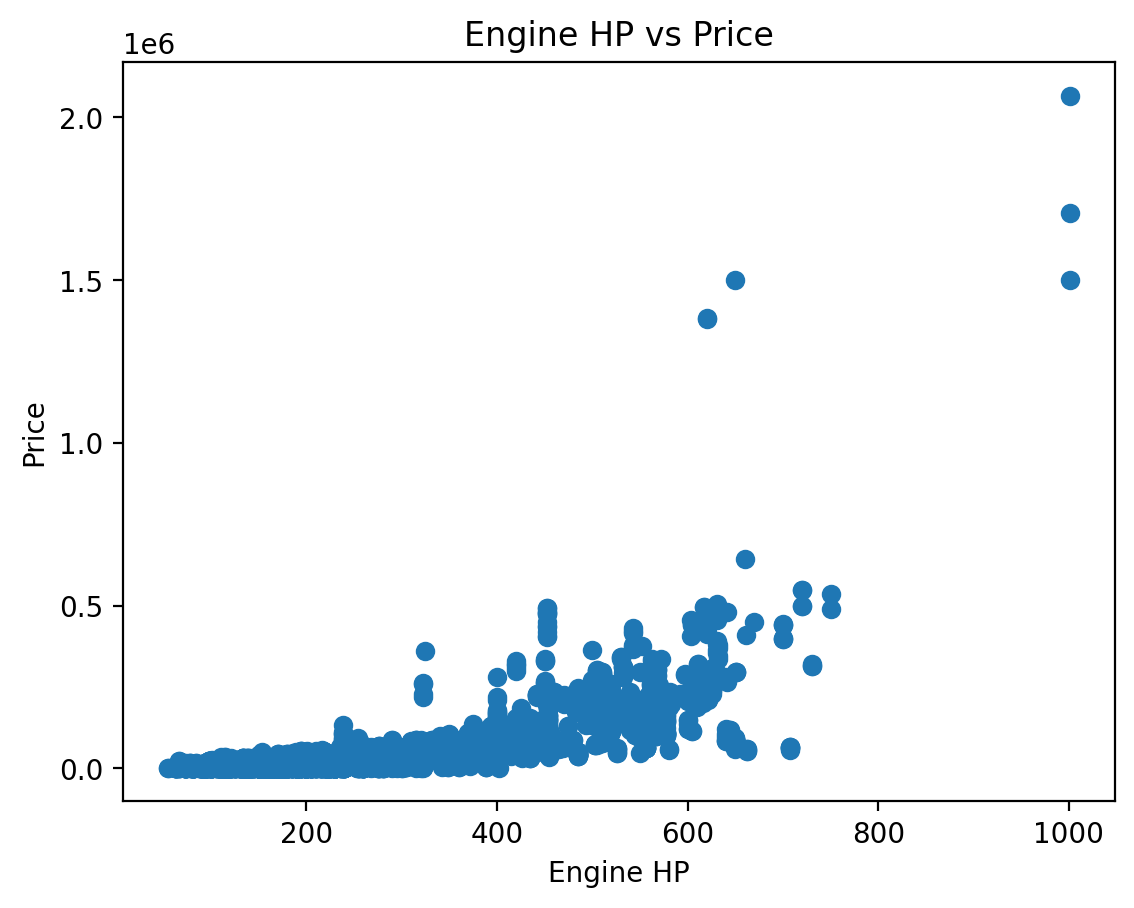

In [ ]:
plt.scatter(df["Engine HP"], df["MSRP"])
plt.title("Engine HP vs Price")
plt.xlabel("Engine HP")
plt.ylabel("Price")
plt.show()

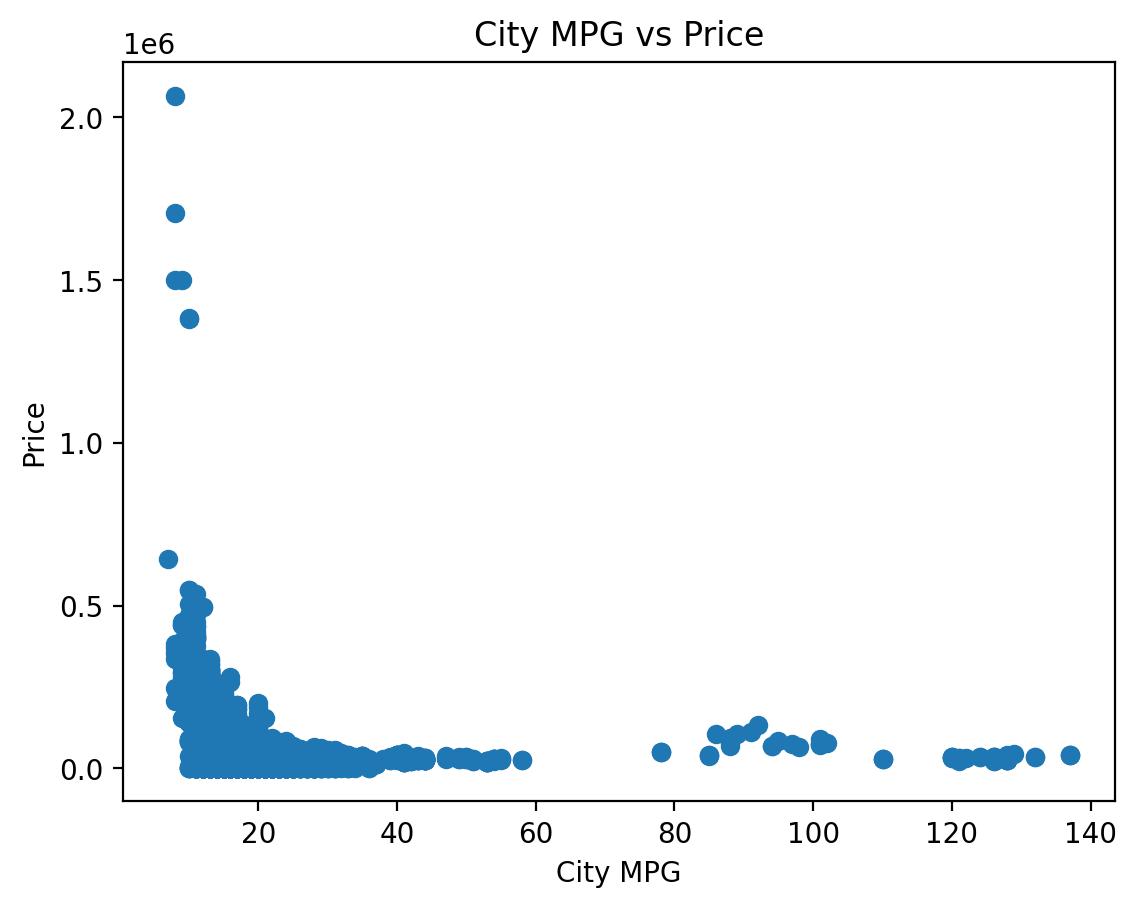

In [ ]:
plt.scatter(df["city mpg"], df["MSRP"])
plt.title("City MPG vs Price")
plt.xlabel("City MPG")
plt.ylabel("Price")
plt.show()

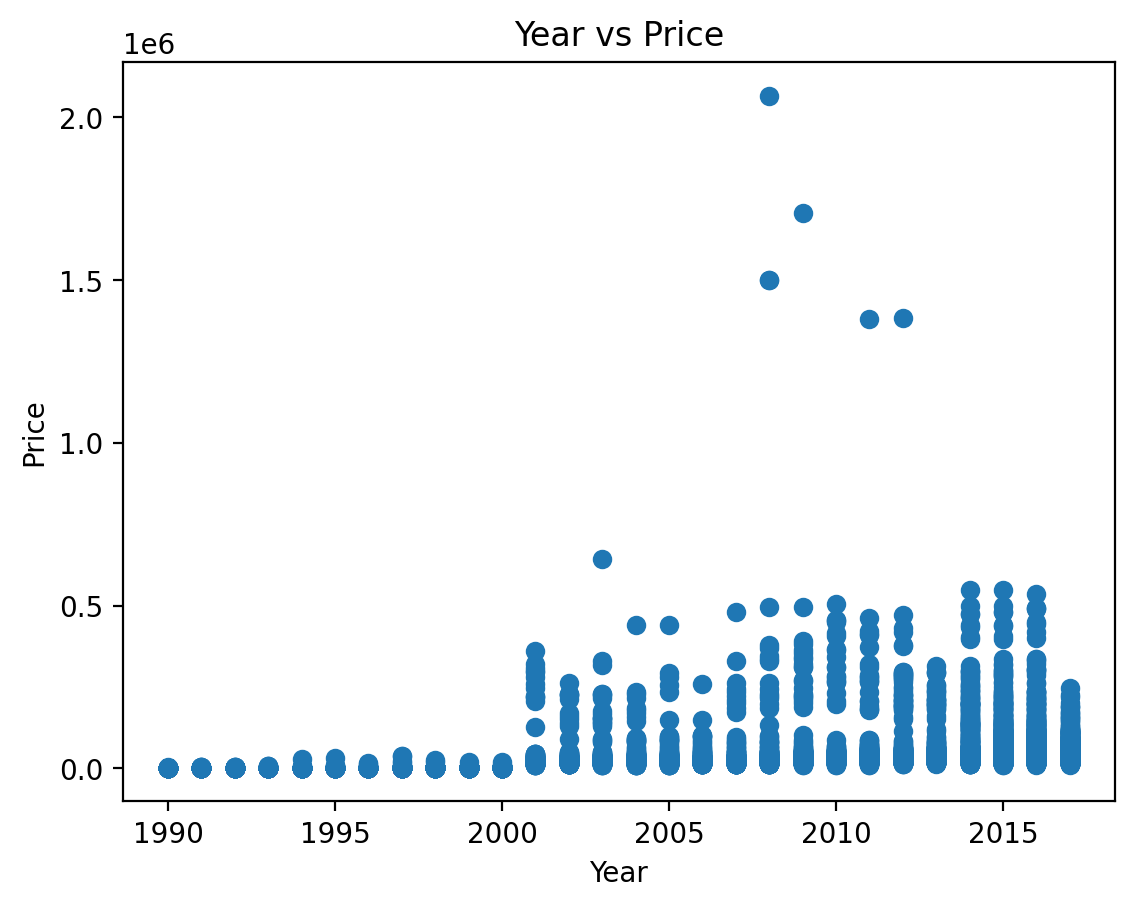

In [ ]:
plt.scatter(df["Year"], df["MSRP"])
plt.title("Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

### Scatter Plot Analysis

The scatter plots provide a clear visualization of the relationships between key features and car prices.

The relationship between Engine HP and price shows a strong positive trend. As engine power increases, car prices tend to increase as well. However, there is noticeable dispersion, especially at higher horsepower levels, indicating that additional factors also influence price.

The relationship between city MPG and price shows a negative trend. Vehicles with higher fuel efficiency (higher MPG) tend to have lower prices, while less efficient vehicles are often more expensive. This aligns with the expectation that high-performance cars consume more fuel and are priced higher.

The relationship between Year and price shows a general upward trend, where newer vehicles tend to be more expensive. However, there is variability within each year, suggesting that factors such as brand, performance, and category also play a significant role in determining price.

### **Research:** Pose relevant questions about your dataset, then answer them using visual elements (e.g. charts or plots) to provide clear insights.

For example, in the 2nd lecture the entire class took a survey. Then, we talked about the collected data and desplayed the collected data using the right **plots** - Lines, Bars, Hist, Pie, Map, HeatMap, Area, Time, etc.

An aditional more specific example, would be the questions we asked during the recitation on the `Titanic` dataset:
  - "Did survival rates differ by gender?"
  - "Was passenger class related to survival?"
  - "What was the age distribution of survivors vs. non-survivors?"
  - "Did embarking location (port) have any effect on survival?"    
  
And how we answered those questions using **plots**.

The idea is to pose questions that can uncover patterns, correlations, or anomalies in your dataset, then back those up with clean, insightful visualizations.

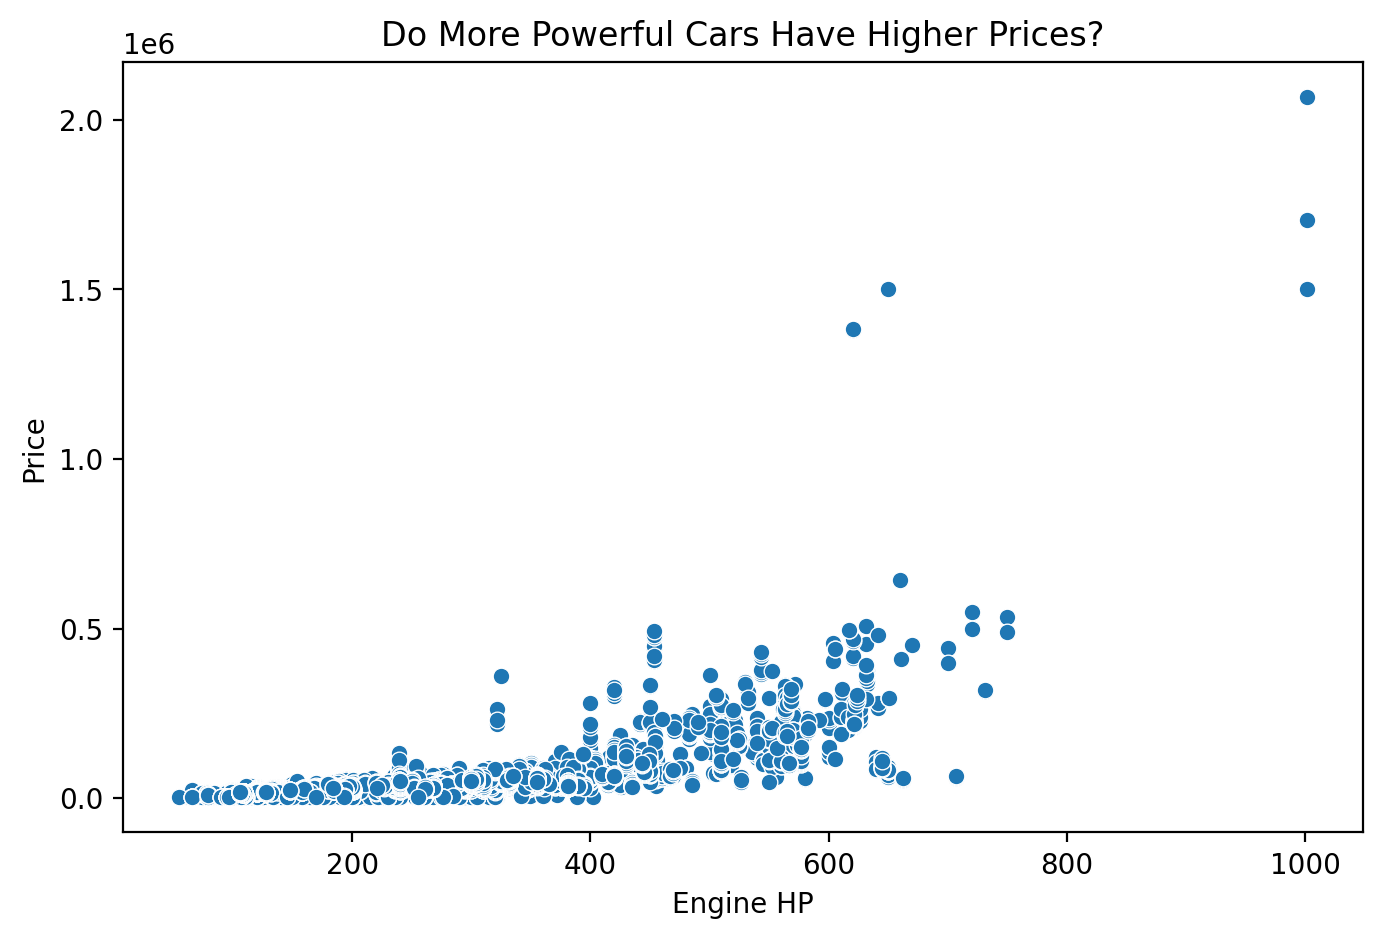

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(x="Engine HP", y="MSRP", data=df)
plt.title("Do More Powerful Cars Have Higher Prices?")
plt.xlabel("Engine HP")
plt.ylabel("Price")
plt.show()

### Research Question 1: Do more powerful cars have higher prices?

The scatter plot shows a clear positive relationship between engine horsepower and car prices. As Engine HP increases, the general trend indicates higher vehicle prices.

However, the relationship is not strictly linear. There is noticeable dispersion, especially in the mid-to-high horsepower range, where cars with similar Engine HP can have significantly different prices.

Additionally, several extreme outliers are visible at very high horsepower levels (around 900–1000 HP), corresponding to exceptionally expensive vehicles.

This suggests that while engine power is a strong indicator of price, other factors such as brand, vehicle type, and market positioning also play a significant role.

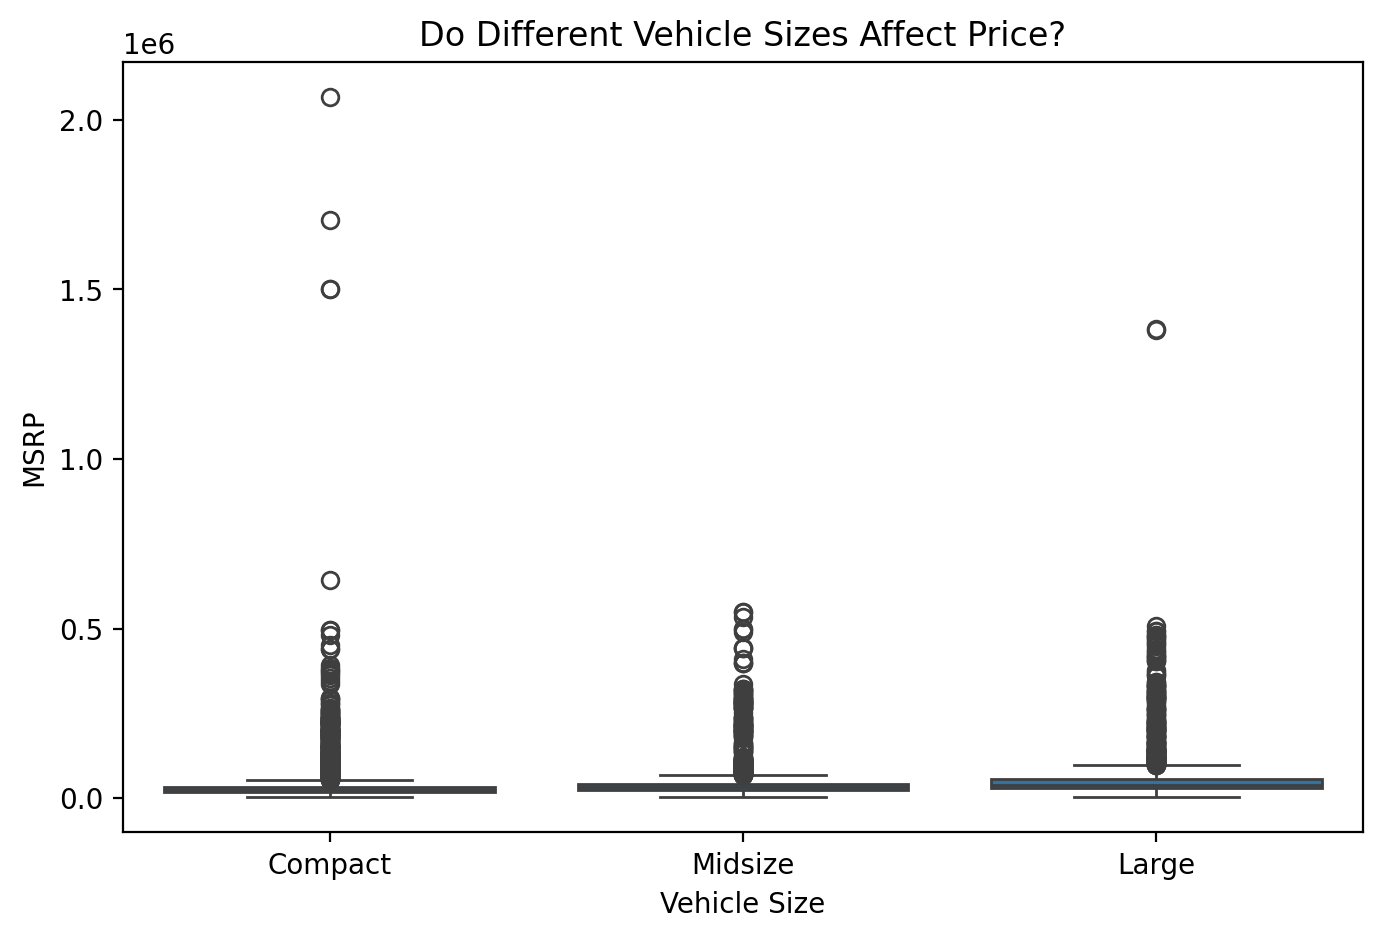

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Vehicle Size", y="MSRP", data=df)
plt.title("Do Different Vehicle Sizes Affect Price?")
plt.show()

### Research Question 2: Do different vehicle sizes affect car prices?

The boxplot shows that vehicle size has an impact on car prices.

Large vehicles tend to have higher median prices compared to Compact and Midsize vehicles. Midsize vehicles are generally priced higher than Compact ones, but the difference is less pronounced.

There is also significant variability in prices within each vehicle size category, with many outliers present. In particular, Compact vehicles show some extremely high-priced outliers, indicating that certain compact cars (likely luxury or performance models) can still be very expensive.

Overall, while larger vehicles tend to be more expensive on average, vehicle size alone does not fully determine price, and other factors such as performance and brand likely play an important role.

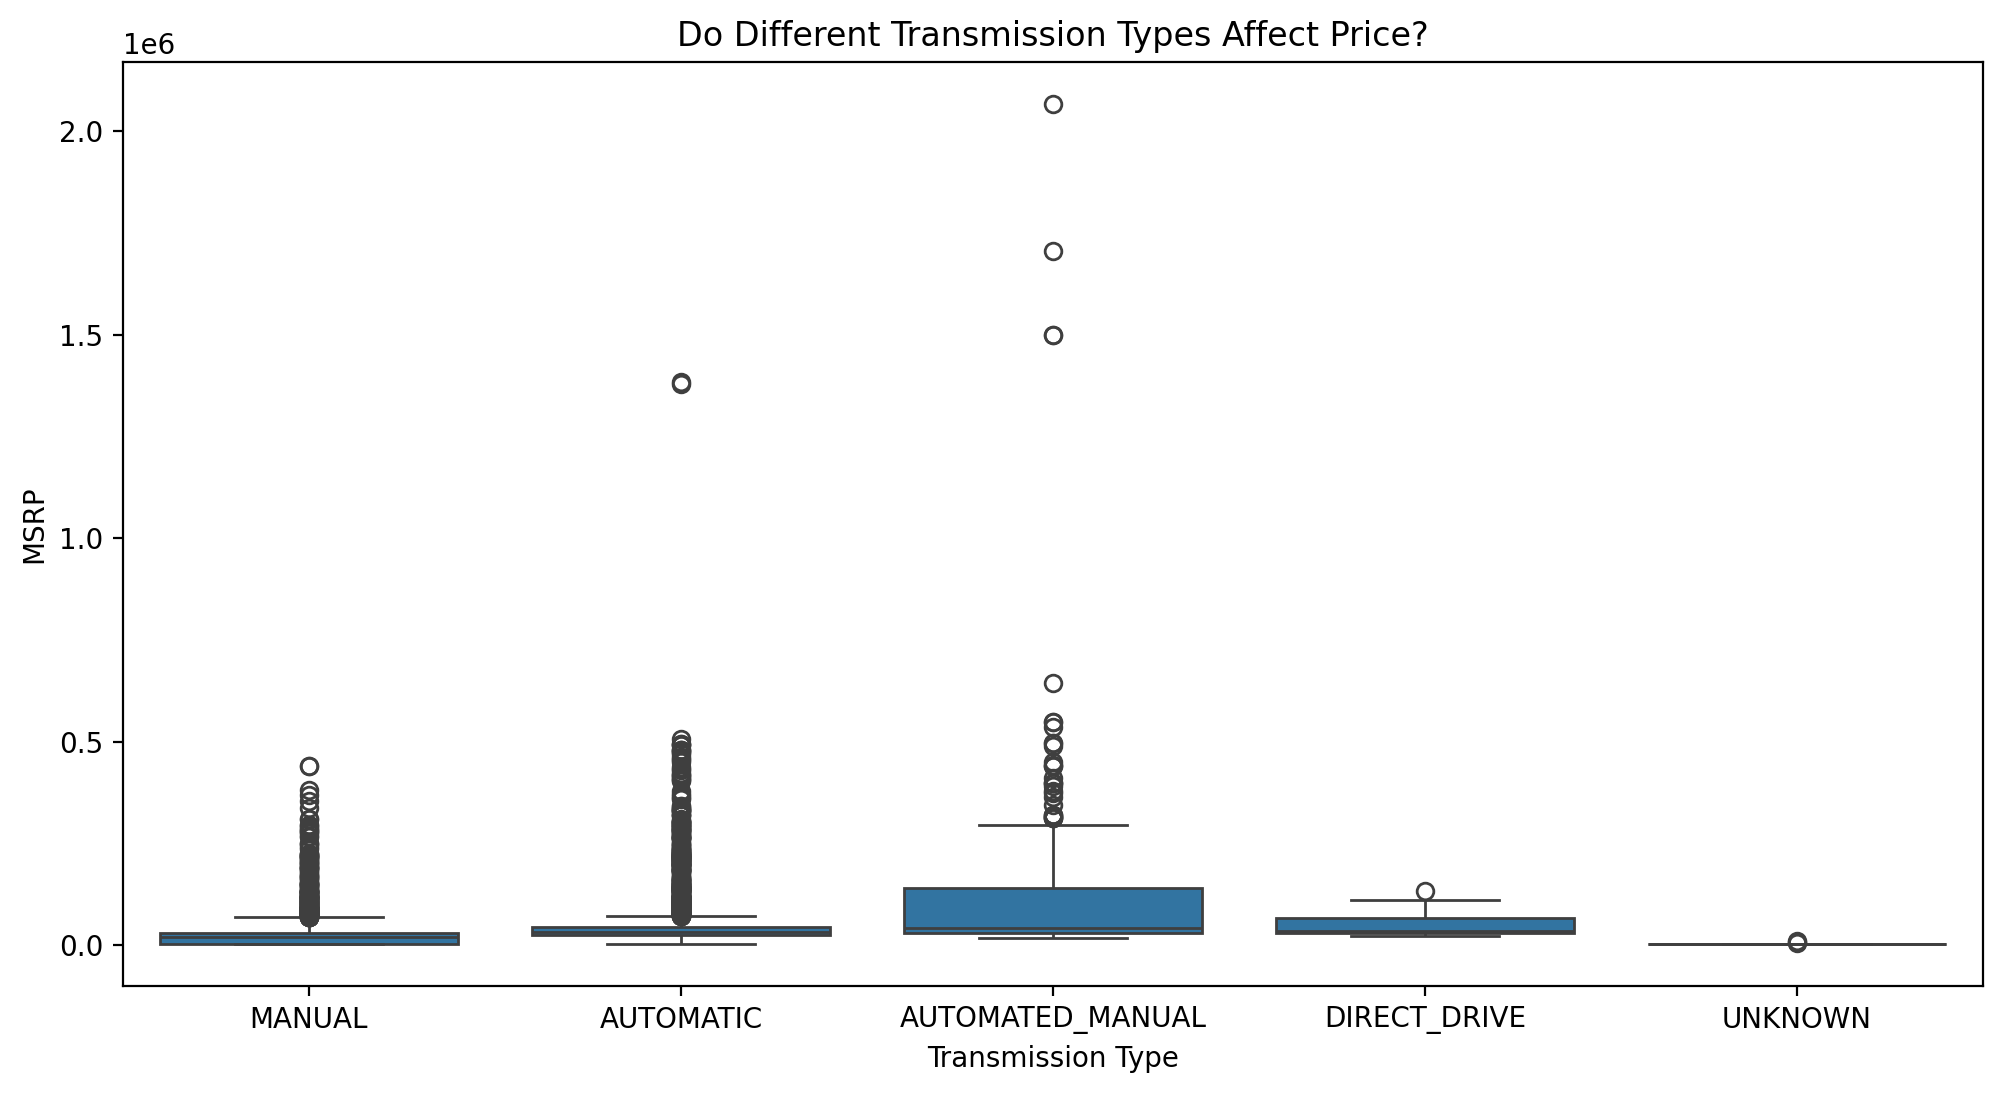

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Transmission Type", y="MSRP", data=df)
plt.title("Do Different Transmission Types Affect Price?")
plt.show()

### Research Question 3: Do different transmission types affect car prices?

The boxplot indicates that transmission type has an effect on car prices.

Vehicles with automatic and automated manual transmissions tend to have higher median prices compared to manual transmission vehicles. In particular, automated manual cars show a wider price range and include some of the highest-priced outliers in the dataset.

Manual transmission vehicles generally appear to be cheaper on average, with a lower median price and a more concentrated distribution.

Direct drive vehicles also show relatively higher prices, although with less variation compared to automated manual transmissions.

The "Unknown" category contains very few observations and therefore does not provide meaningful insight.

Overall, transmission type appears to influence car pricing, but the presence of large variability suggests that other factors such as engine performance and vehicle category also play a significant role.

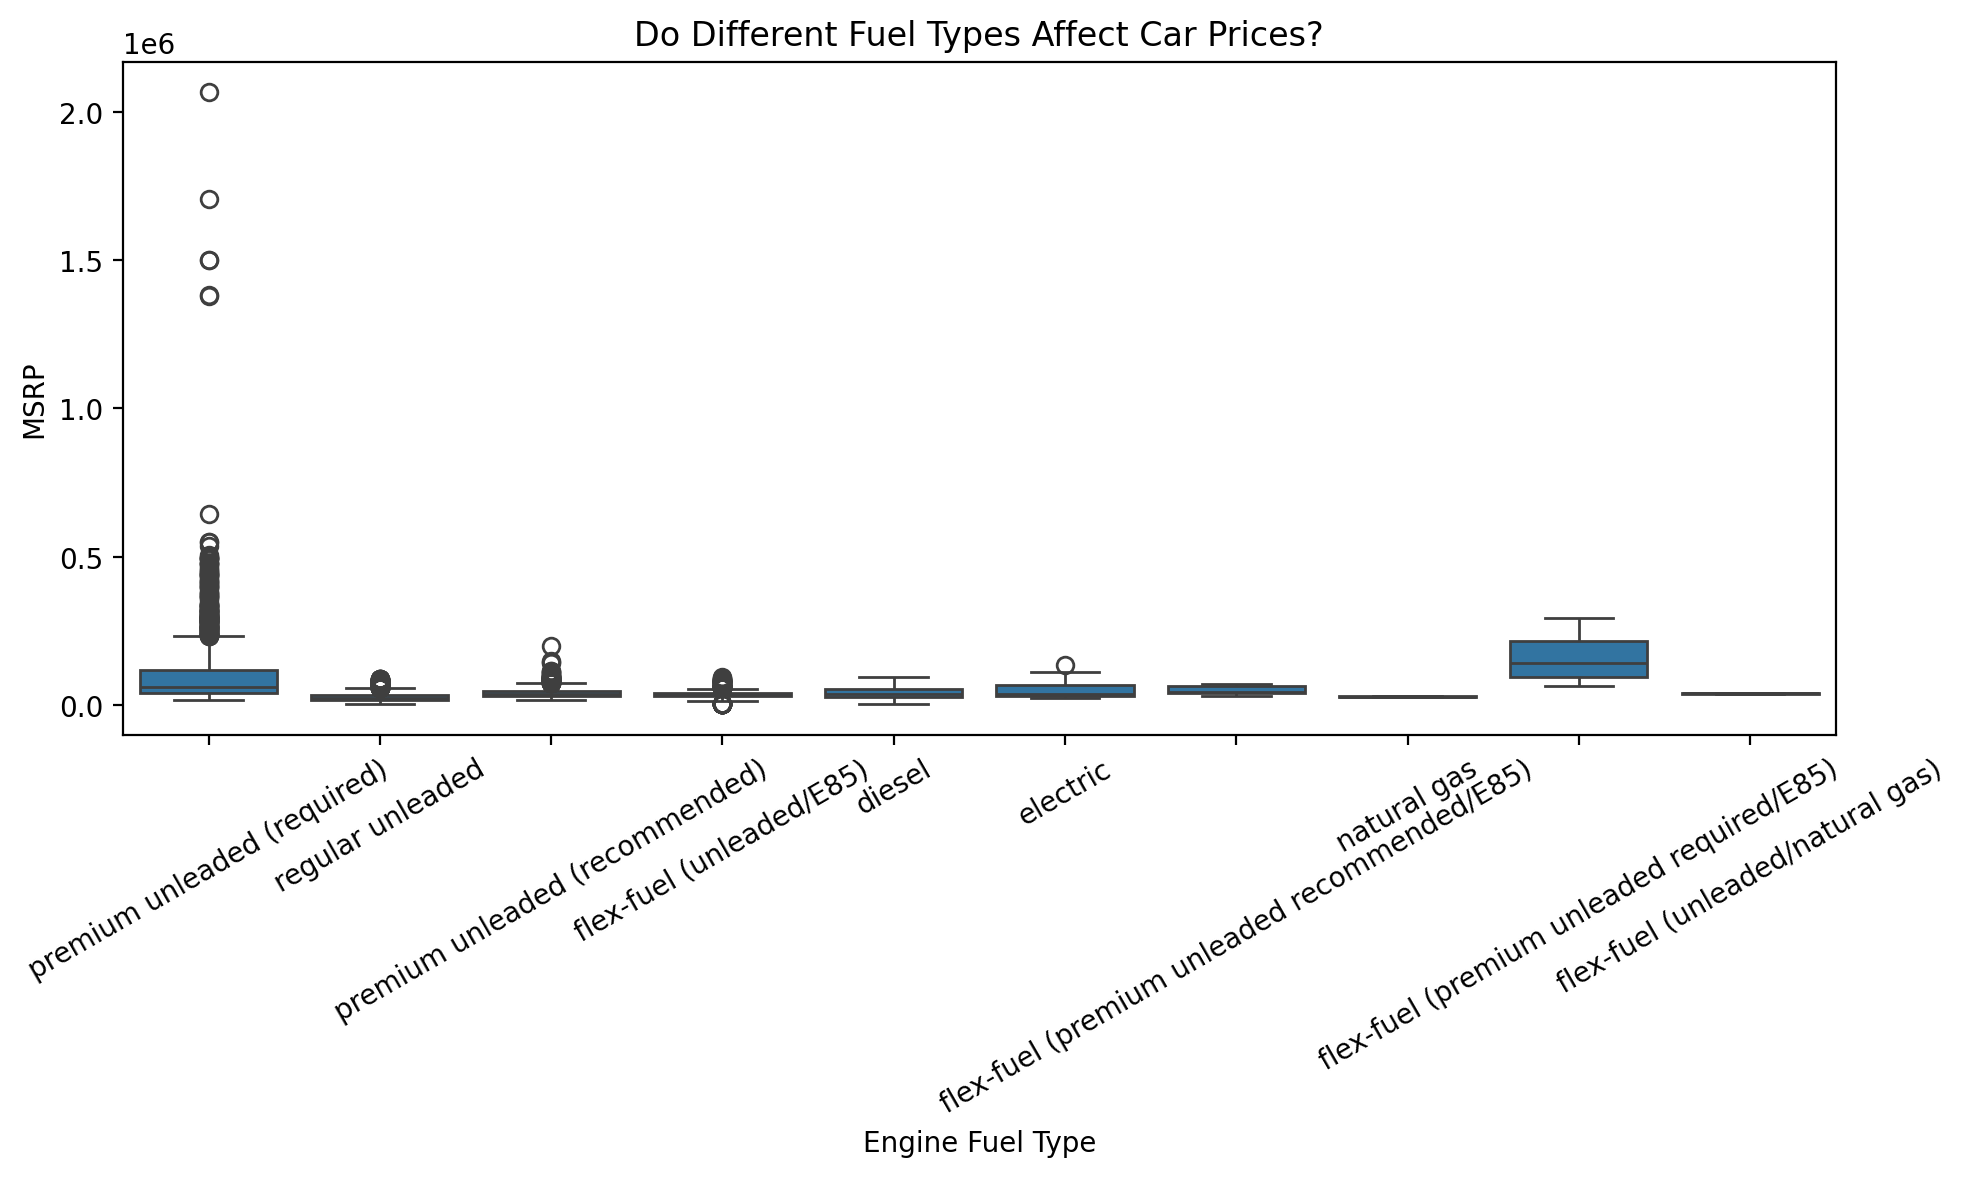

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Engine Fuel Type", y="MSRP", data=df)

plt.xticks(rotation=30)
plt.title("Do Different Fuel Types Affect Car Prices?")
plt.tight_layout()

plt.show()

### Research Question 4: Do different fuel types affect car prices?

The boxplot shows that fuel type has a noticeable impact on car prices.

Vehicles that use premium unleaded fuel tend to have higher prices on average and also include some of the most expensive outliers in the dataset. This suggests that high-performance or luxury vehicles are more likely to require premium fuel.

In contrast, vehicles using regular unleaded fuel generally have lower prices, with a more concentrated and lower distribution.

Electric vehicles appear to have relatively higher median prices compared to standard fuel types, although the range is more limited.

Diesel and flex-fuel vehicles fall in the mid-range, with moderate price levels and less extreme variability.

Some fuel categories have very few observations, making it difficult to draw strong conclusions for those groups.

Overall, fuel type is associated with price differences, but it likely reflects underlying factors such as vehicle performance, technology, and market positioning rather than being a direct cause of price differences.

<br><br><br>

---

<br><br><br>

# **Part 3: Define and Train a baseline model**

1. **Regression Goal**: Clearly state the problem you’re addressing.

2. **Feature Selection**: Identify the features that seem most relevant. It’s fine to start with all features if you’re unsure.

3. **Train-Test Split**: Partition your data into training, and testing sets. Use simple sampling. Quick reminder - when using ramdom - Use `Seed`!

4. **Model Training**: For simplicity, start with default parameters on a `Linear Regression` model, using scikit-learn. Focus on establishing a baseline.

5. **Model Evaluation**: Present straightforward metrics such as MAE, MSE, RMSE, R2, etc.

6. **Insights**: Summarize the model’s performance with visuals.

7. **Feature Importance:** Explain & Visualize  `feature importance` by looking on the `coefficients` of the Linear Regression model .

<br>

*FYI: Sections 5 and 6 will be repeated throughout your work.*

In [ ]:
# Drop columns
df_model = df.drop(["Make", "Model", "Market Category"], axis=1)

# Target
y = df_model["log_MSRP"]

# Features
X = df_model.drop(["MSRP", "log_MSRP"], axis=1)

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.3388009728064795
RMSE: 0.4488209348287497
R²: 0.8221456726646347


### Model Evaluation — Linear Regression

A Linear Regression model was trained to predict the log-transformed car prices (log_MSRP).

The model achieved an R² score of 0.82, indicating that it explains approximately 82% of the variance in car prices. This suggests a strong relationship between the selected features and the target variable.

The Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) values indicate that the model's predictions are reasonably accurate, with moderate prediction errors.

Overall, the Linear Regression model performs well and serves as a solid baseline for further improvements.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

MAE: 0.07903591659882596
RMSE: 0.10933867002606412
R²: 0.9894448162469524


In [ ]:
X.columns

Index(['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors',
       'highway MPG', 'city mpg', 'Popularity', 'Engine Fuel Type_electric',
       'Engine Fuel Type_flex-fuel (premium unleaded recommended/E85)',
       'Engine Fuel Type_flex-fuel (premium unleaded required/E85)',
       'Engine Fuel Type_flex-fuel (unleaded/E85)',
       'Engine Fuel Type_flex-fuel (unleaded/natural gas)',
       'Engine Fuel Type_natural gas',
       'Engine Fuel Type_premium unleaded (recommended)',
       'Engine Fuel Type_premium unleaded (required)',
       'Engine Fuel Type_regular unleaded', 'Transmission Type_AUTOMATIC',
       'Transmission Type_DIRECT_DRIVE', 'Transmission Type_MANUAL',
       'Transmission Type_UNKNOWN', 'Driven_Wheels_four wheel drive',
       'Driven_Wheels_front wheel drive', 'Driven_Wheels_rear wheel drive',
       'Vehicle Size_Large', 'Vehicle Size_Midsize', 'Vehicle Style_2dr SUV',
       'Vehicle Style_4dr Hatchback', 'Vehicle Style_4dr SUV',
       'Vehicle Styl

### Model Comparison

Two models were evaluated in this project: Linear Regression and Random Forest.

The Linear Regression model achieved an R² score of 0.82, providing a strong baseline and demonstrating that the selected features have a meaningful linear relationship with car prices.

The Random Forest model significantly outperformed Linear Regression, achieving an R² score of 0.99. This indicates that non-linear relationships and feature interactions play an important role in predicting car prices.

While Random Forest provides superior performance, Linear Regression remains valuable for its interpretability and simplicity.

### Conclusion

In this project, we analyzed a car dataset to understand the factors that influence vehicle prices and built predictive models to estimate car prices.

Exploratory Data Analysis revealed that features such as engine power, number of cylinders, vehicle size, and fuel type are strongly related to price.

A log transformation was applied to the target variable to improve model performance.

The Random Forest model achieved the best results, demonstrating that car pricing is influenced by complex, non-linear relationships between features.

This project highlights the importance of both data exploration and model selection in building accurate predictive systems.

<br><br><br>

---

<br><br><br>

# **Part 4: Feature Engineering**

* Create, transform, scale, or extract new features; encoding categoricals, polynomial features, PCA, etc.
*TIP: use sklearn's tools, such as Scalar, One-Hot, etc.*

* To achieve the best possible results on the assignment, make extensive use of feature engineering.

* Use a `Clustring Model` to create a new feature.

In [ ]:
# Age of car
df["car_age"] = 2024 - df["Year"]

# Combined fuel efficiency
df["mpg_combined"] = (df["city mpg"] + df["highway MPG"]) / 2

# Engine efficiency
df["hp_per_cylinder"] = df["Engine HP"] / df["Engine Cylinders"]

In [ ]:
import numpy as np

np.isinf(df.select_dtypes(include=['int64', 'float64'])).sum()

,0
Year,0
Engine HP,0
Engine Cylinders,0
Number of Doors,0
highway MPG,0
city mpg,0
Popularity,0
MSRP,0
log_MSRP,0
car_age,0


In [ ]:
df["hp_per_cylinder"] = df["hp_per_cylinder"].replace([np.inf, -np.inf], np.nan)
df["hp_per_cylinder"] = df["hp_per_cylinder"].fillna(df["hp_per_cylinder"].median())

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_features = df.select_dtypes(include=['int64', 'float64'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_features)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(scaled_data)

During feature engineering, the `hp_per_cylinder` feature produced invalid values due to division by zero in some observations. These infinite values were replaced with missing values and then imputed using the median.

In [ ]:
df["cluster"].value_counts()

,count
cluster,
2,5068
1,3635
0,2496


### Clustering Results

The K-Means algorithm divided the dataset into three clusters.

The distribution of observations across clusters is relatively balanced, with cluster 2 being the largest group, followed by cluster 1 and cluster 0.

This suggests that the dataset naturally forms distinct groups of vehicles with different characteristics. These clusters likely represent different segments such as economy, mid-range, and high-performance vehicles.

The cluster feature will be used to enhance model performance by capturing hidden patterns in the data.

### **Applying Clustering (Unsupervised Learning):**

* Run at least one clustering algorithm; K-Means, DBSCAN, etc.
* Visualize the clusters using dimensionality reduction (PCA, t-SNE, UMAP).
* Interpret the clusters: What makes them distinct? Are they useful?
* Use the results to create new features (e.g., cluster ID, distance to centroid, cluster probabilities).


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

df["pca1"] = pca_data[:, 0]
df["pca2"] = pca_data[:, 1]

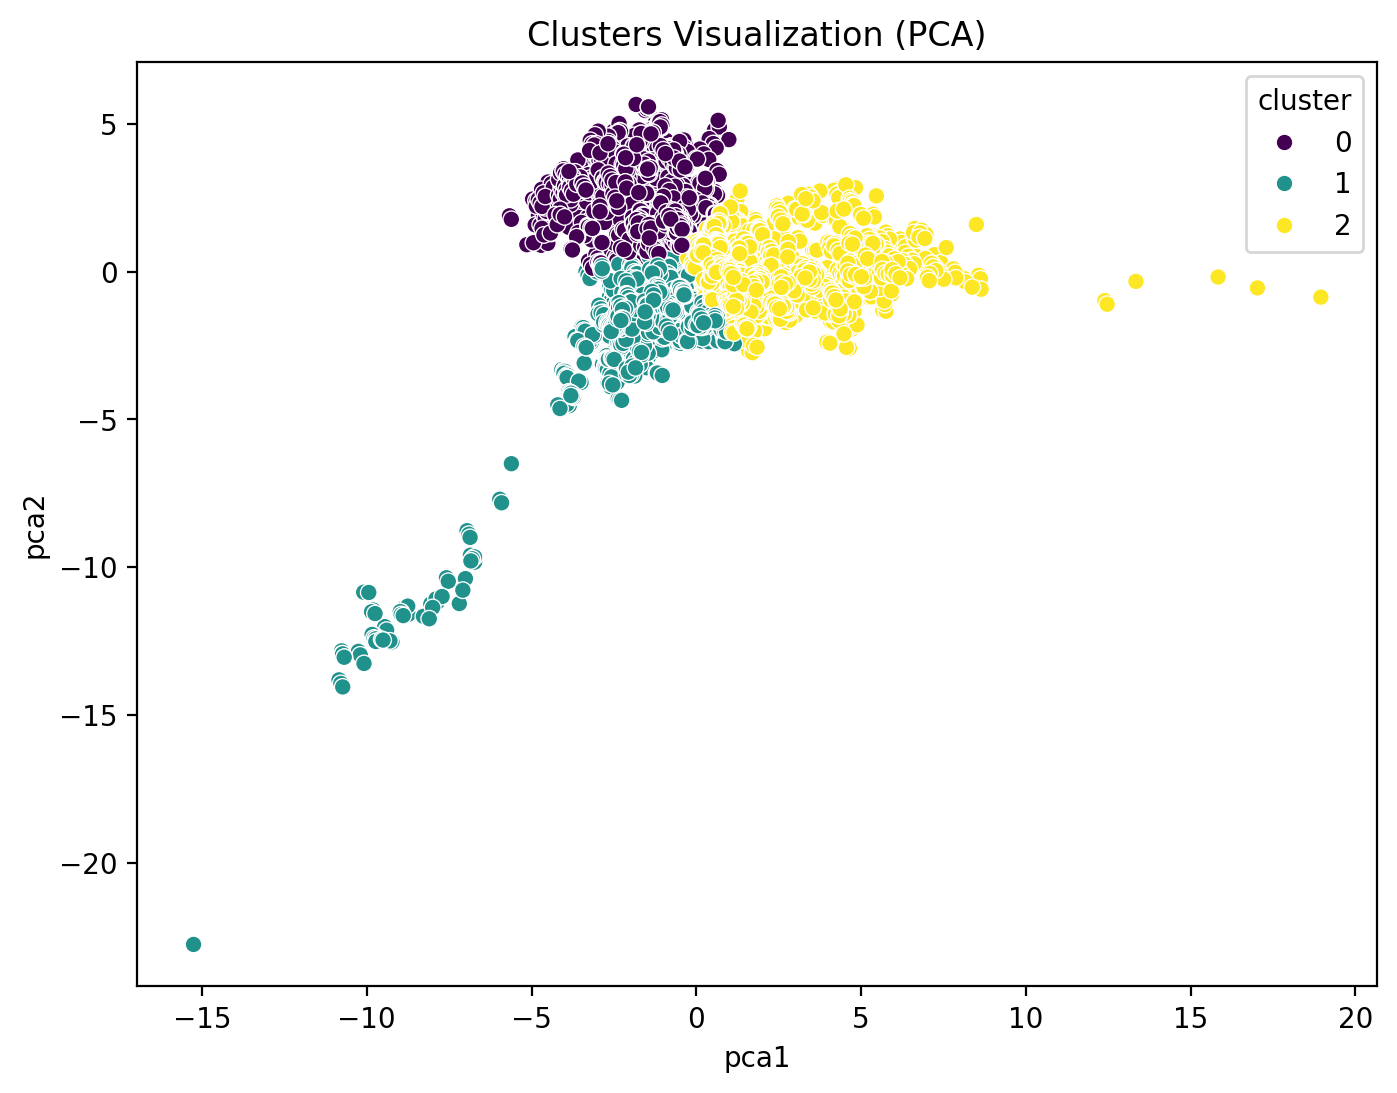

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(x="pca1", y="pca2", hue="cluster", data=df, palette="viridis")
plt.title("Clusters Visualization (PCA)")
plt.show()

### Cluster Visualization (PCA)

The PCA visualization shows a clear separation between the three clusters identified by the K-Means algorithm.

Each cluster forms a relatively distinct group in the reduced two-dimensional space, indicating that the clustering algorithm successfully captured meaningful patterns in the data.

Cluster 2 appears to be more spread out and extends further along the first principal component, suggesting greater variability within this group. In contrast, clusters 0 and 1 are more compact and concentrated.

There are also a few extreme observations that are clearly separated from the main groups, indicating the presence of outliers in the dataset.

Overall, the visualization confirms that the clustering structure is meaningful and can provide useful additional information for predictive modeling.

<br><br><br>

---

<br><br><br>

# **Part 5: Train and Evaluate Three Improved Models**

* Retrain your `Linear Regression` model with the engineered features.
* Choose and Train two different types on models from the SKlearn package (DOCS), on the engineered dataset.
* Compare performance with your baseline.
* Visualize feature importance.
* <u>Discuss the improvement and the reasons.</u>
* Declare the winner.

In [ ]:
import pandas as pd
import numpy as np

# Build engineered modeling dataset
df_eng = df.copy()

# Drop raw text columns that are too high-cardinality / messy for now
df_eng = df_eng.drop(["Make", "Model", "Market Category", "pca1", "pca2"], axis=1, errors="ignore")

# Target
y = df_eng["log_MSRP"]

# Features
X = df_eng.drop(["MSRP", "log_MSRP"], axis=1)

# One-hot encode categoricals
X = pd.get_dummies(X, drop_first=True)

X.shape

(11199, 44)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"--- {name} ---")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R²:", r2)
    print()

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_gb, "Gradient Boosting")

--- Linear Regression ---
MAE: 0.3384056005054008
RMSE: 0.44818636242245197
R²: 0.8226482413028834

--- Random Forest ---
MAE: 0.07921224452096029
RMSE: 0.11086278678949887
R²: 0.9891484991896344

--- Gradient Boosting ---
MAE: 0.12283504762751483
RMSE: 0.16720379322200116
R²: 0.9753162877010196



### Improved Models Evaluation

Three models were trained on the engineered dataset: Linear Regression, Random Forest, and Gradient Boosting.

The Linear Regression model achieved an R² score of 0.82, providing a solid baseline but limited by its inability to capture non-linear relationships.

Gradient Boosting significantly improved performance, achieving an R² of 0.97, demonstrating its ability to model complex patterns in the data.

The Random Forest model achieved the best results, with an R² score of 0.989 and the lowest error metrics (MAE and RMSE). This indicates that it captures both non-linear relationships and feature interactions effectively.

Overall, ensemble-based models significantly outperformed the linear model, highlighting the importance of non-linear modeling in predicting car prices.

### Winning Model

The Random Forest model was selected as the final model due to its superior performance across all evaluation metrics.

It achieved the highest R² score and the lowest prediction errors, making it the most accurate model for predicting car prices in this dataset.

In [ ]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)

,0
car_age,0.385148
Year,0.321767
Engine HP,0.228250
Engine Cylinders,0.011204
city mpg,0.009189
Popularity,0.007380
hp_per_cylinder,0.006756
mpg_combined,0.004572
Engine Fuel Type_premium unleaded (required),0.003579
highway MPG,0.002852


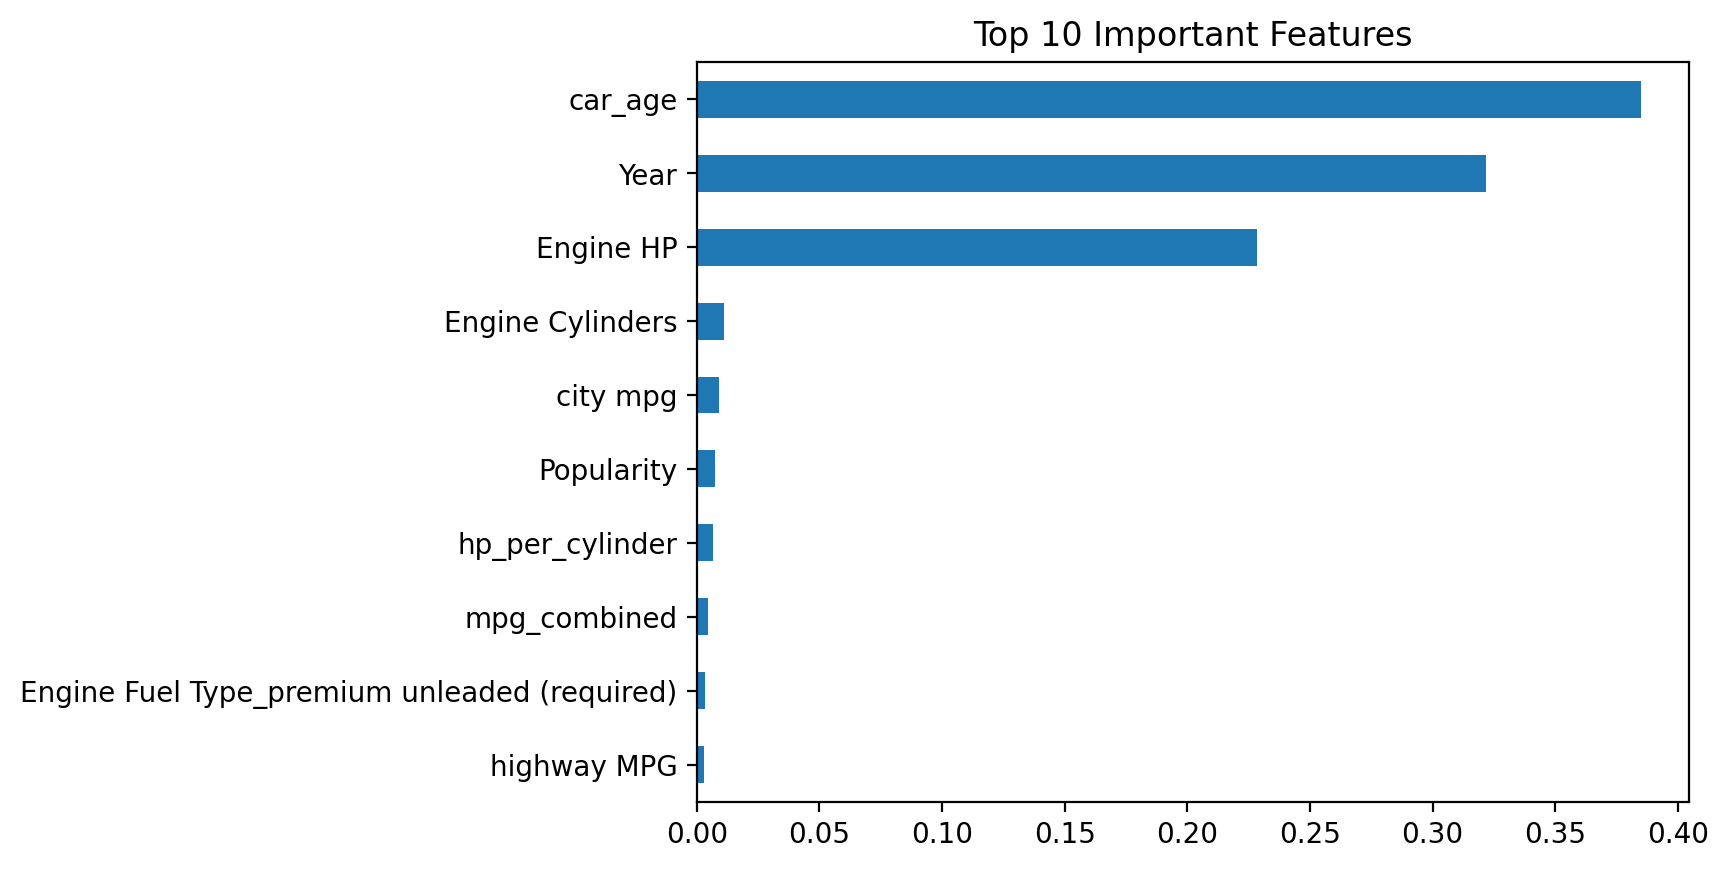

In [ ]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

### Feature Importance Analysis

The feature importance results from the Random Forest model reveal that car age is the most influential factor in predicting vehicle price, followed by the manufacturing year and engine horsepower.

This indicates that depreciation over time plays a critical role in determining a car’s value, while performance-related features such as engine power also contribute significantly.

Interestingly, fuel efficiency (city and highway MPG), popularity, and fuel type have relatively low importance, suggesting that they have a limited impact on price compared to age and performance.

It is also worth noting that car_age and Year are highly related features, which may introduce redundancy in the model.

<br><br><br>

---

<br><br><br>

# Part 6: Winning Model

1. Open a new <u>HuggingFace Model Repository.</u>
2. Export the winning model to a `pickle` file.
3. Upload the pickle file to your new model repository on `HF`.

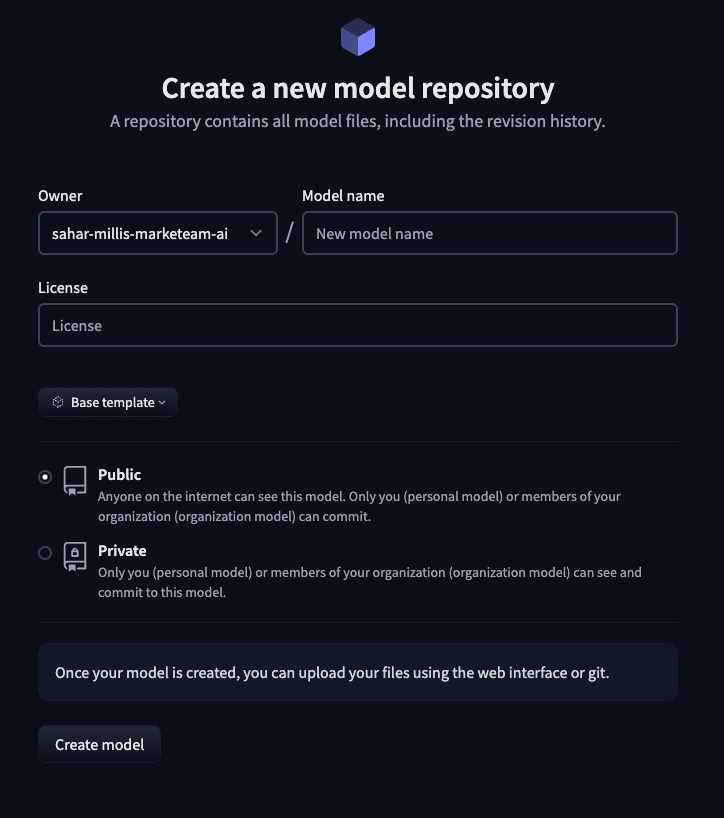

In [ ]:
import pickle

with open("car_price_model.pkl", "wb") as f:
    pickle.dump(rf, f)

<br><br><br>

---

<br><br><br>

## Part 7: Regression-to-Classification

In this section, you will **reframe your original regression problem as a classification problem**.
This means transforming your continuous numeric target into **discrete classes**, and then training classification models to predict those classes.








#### **7.1 Create Classes From Your Numeric Target**

Your first task is to convert the continuous target `y` into categories. Choose a strategy to convert your numeric target into classes. For example:


* Median Split (Binary Classification)**
```
Class 0: values **below the median**
Class 1: values **at or above the median**
```

* Quantile Binning (3+ Classes)**
```
>  * Class 0: bottom 33%
>  * Class 1: middle 33%
>  * Class 2: top 33%
```

* Business Rule Threshold** - You define a meaningful cutoff, e.g.:
```
* High-value customer if revenue > X
* “Expensive” product if price > Y
```

**Tasks:**

1. Implement your chosen strategy on the **train** and **test** targets. Using the **same engineered features** as before.

2. Explain the reasoning behind your choice (2–3 sentences).

In [ ]:
# Create 3 classes based on quantiles
df_eng["price_class"] = pd.qcut(
    df_eng["log_MSRP"],
    q=3,
    labels=[0, 1, 2]
)

In [ ]:
X_cls = X.copy()
y_cls = df_eng["price_class"]

### Regression to Classification

The regression problem was transformed into a classification task by converting the continuous price variable into three categories using quantile-based binning.

The dataset was divided into three equally sized groups:
- Class 0: Low-priced vehicles
- Class 1: Mid-range vehicles
- Class 2: High-priced vehicles

This approach ensures a balanced class distribution and allows the model to capture different price segments.


#### **7.2 Check Class Balance**

Before training your classifier, examine if the classes are balanced.

1. Show the resulting **class distribution** (counts or percentages).
2. Are some classes under-represented?
3. If the data is imbalanced, explain which metric you’ll focus on (e.g., F1 score, recall) and why accuracy alone is misleading.
4. If needed, consider changing your convertion.

In [ ]:
y_cls.value_counts()

,count
price_class,
1,3736
0,3733
2,3730


In [ ]:
y_cls.value_counts(normalize=True)

,proportion
price_class,
1,0.333601
0,0.333333
2,0.333065


### Class Distribution

The class distribution is well-balanced, with each class representing approximately one-third of the dataset.

This balance is a result of using quantile-based binning, which ensures that each class contains a similar number of observations.

Since the classes are evenly distributed, there is no issue of class imbalance, and standard evaluation metrics such as accuracy can be used reliably.

<br><br><br>

---

<br><br><br>

# Part 8: Train & Eval Classification Models



#### 8.1 Answer the following, and mentioned it in your presentation.



In the context of your dataset/task, explain what would be more importatnt - <u>precision or recall.</u>



### Precision vs Recall

In this project, precision is slightly more important than recall.

If the model predicts that a car belongs to a higher price class when it actually does not, it may lead to overestimating the car's value. This could mislead buyers or sellers and result in poor pricing decisions.

Therefore, it is especially important that predictions of expensive cars are accurate.

In the context of your dataset/task, explain what would be more critical - <u>False Positive or False Negative.</u>


### False Positives vs False Negatives

In this context, false positives are more critical than false negatives.

A false positive means predicting that a car belongs to a higher price class than it actually does. This may lead to overpricing or overestimating the vehicle's value.

False negatives are less harmful because they result in a more conservative estimate.

#### 8.2: Train **three** different kinds of classification models.


Go to SKlearn to find different classification models. And use them.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

log_clf = LogisticRegression(max_iter=2000)
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
gb_clf = GradientBoostingClassifier(random_state=42)

log_clf.fit(X_train_cls, y_train_cls)
rf_clf.fit(X_train_cls, y_train_cls)
gb_clf.fit(X_train_cls, y_train_cls)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_pred_log = log_clf.predict(X_test_cls)
y_pred_rf = rf_clf.predict(X_test_cls)
y_pred_gb = gb_clf.predict(X_test_cls)

#### 8.3: Evaluation

- Evaluate the Classification Models.

- For each print the `classification report` (precision, recall, F1-score, support), and show a `confusion matrix`. (use SKlean built tools) Comment on what types of mistakes the model makes (based on the confusion matrix).

- Identify which model performs best and **why**.



===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       747
           1       0.69      0.69      0.69       747
           2       0.83      0.82      0.82       746

    accuracy                           0.79      2240
   macro avg       0.79      0.79      0.79      2240
weighted avg       0.79      0.79      0.79      2240



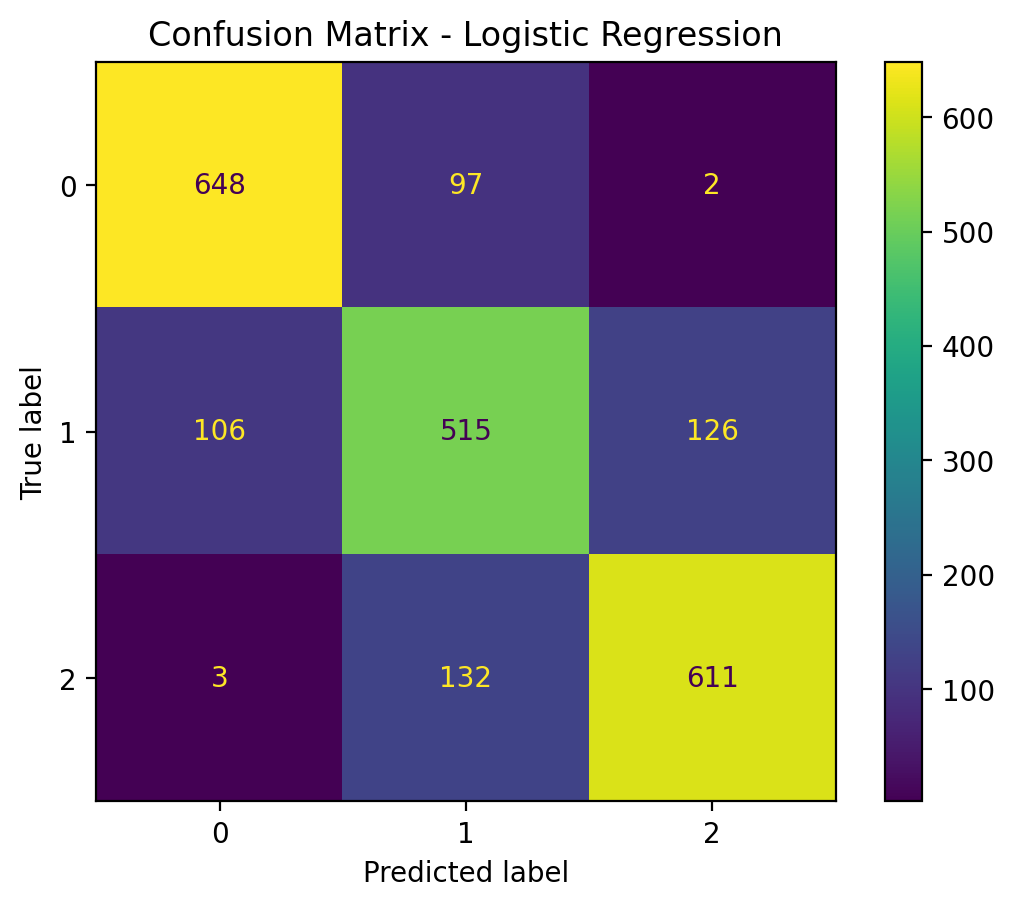

===== Random Forest Classifier =====
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       747
           1       0.81      0.83      0.82       747
           2       0.90      0.89      0.89       746

    accuracy                           0.88      2240
   macro avg       0.88      0.88      0.88      2240
weighted avg       0.88      0.88      0.88      2240



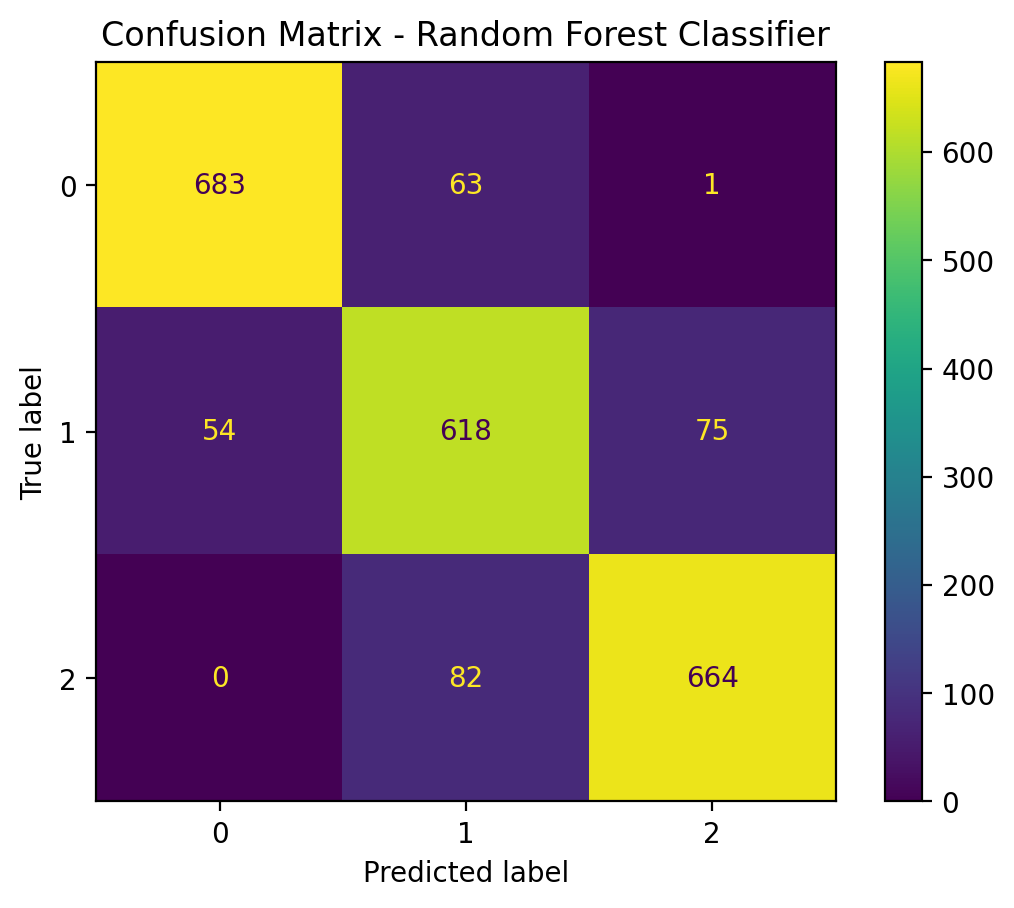

===== Gradient Boosting Classifier =====
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       747
           1       0.80      0.84      0.82       747
           2       0.91      0.89      0.90       746

    accuracy                           0.88      2240
   macro avg       0.88      0.88      0.88      2240
weighted avg       0.88      0.88      0.88      2240



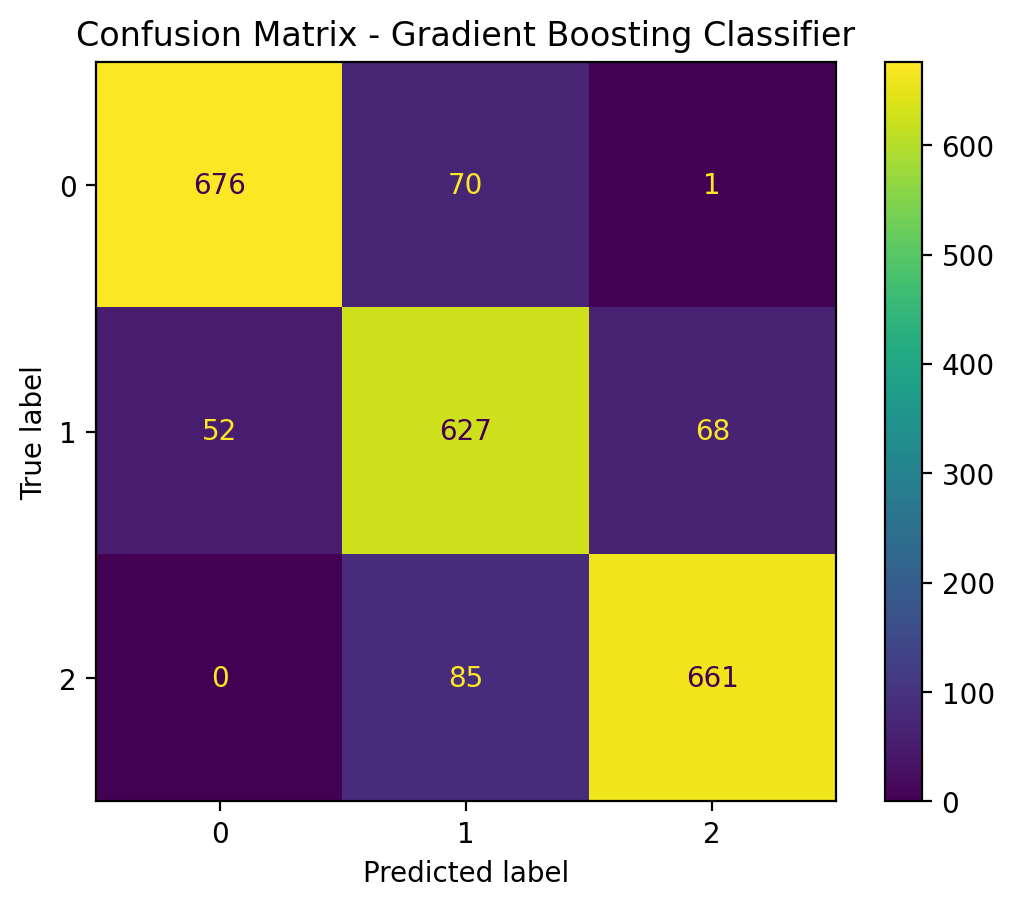

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_classifier(model_name, y_true, y_pred):
    print(f"===== {model_name} =====")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

evaluate_classifier("Logistic Regression", y_test_cls, y_pred_log)
evaluate_classifier("Random Forest Classifier", y_test_cls, y_pred_rf)
evaluate_classifier("Gradient Boosting Classifier", y_test_cls, y_pred_gb)

### Classification Model Evaluation

Three classification models were evaluated: Logistic Regression, Random Forest, and Gradient Boosting.

The Logistic Regression model achieved an accuracy of 0.79, providing a reasonable baseline but struggling to capture complex relationships in the data.

Both Random Forest and Gradient Boosting significantly improved performance, achieving an accuracy of 0.88.

The models performed well on the low-price and high-price classes, but showed more difficulty in predicting the mid-range class, which likely has overlapping characteristics with both other groups.

Overall, ensemble models demonstrated a clear advantage over the linear model.

#### 8.4: Winner

- Choose the best one out of the three models.

- Export the model to a `pickle` file.

- Upload the pickle file to the same(!) model repository.


### Classification Model Evaluation

Three classification models were evaluated: Logistic Regression, Random Forest, and Gradient Boosting.

The Logistic Regression model achieved an accuracy of 0.79, providing a reasonable baseline but struggling to capture complex relationships in the data.

Both Random Forest and Gradient Boosting significantly improved performance, achieving an accuracy of 0.88.

The models performed well on the low-price and high-price classes, but showed more difficulty in predicting the mid-range class, which likely has overlapping characteristics with both other groups.

Overall, ensemble models demonstrated a clear advantage over the linear model.

In [ ]:
import pickle

with open("car_price_classifier.pkl", "wb") as f:
    pickle.dump(rf_clf, f)

<br><br><br>

---

<br><br><br>

<br><br><br>

---

<br><br><br>